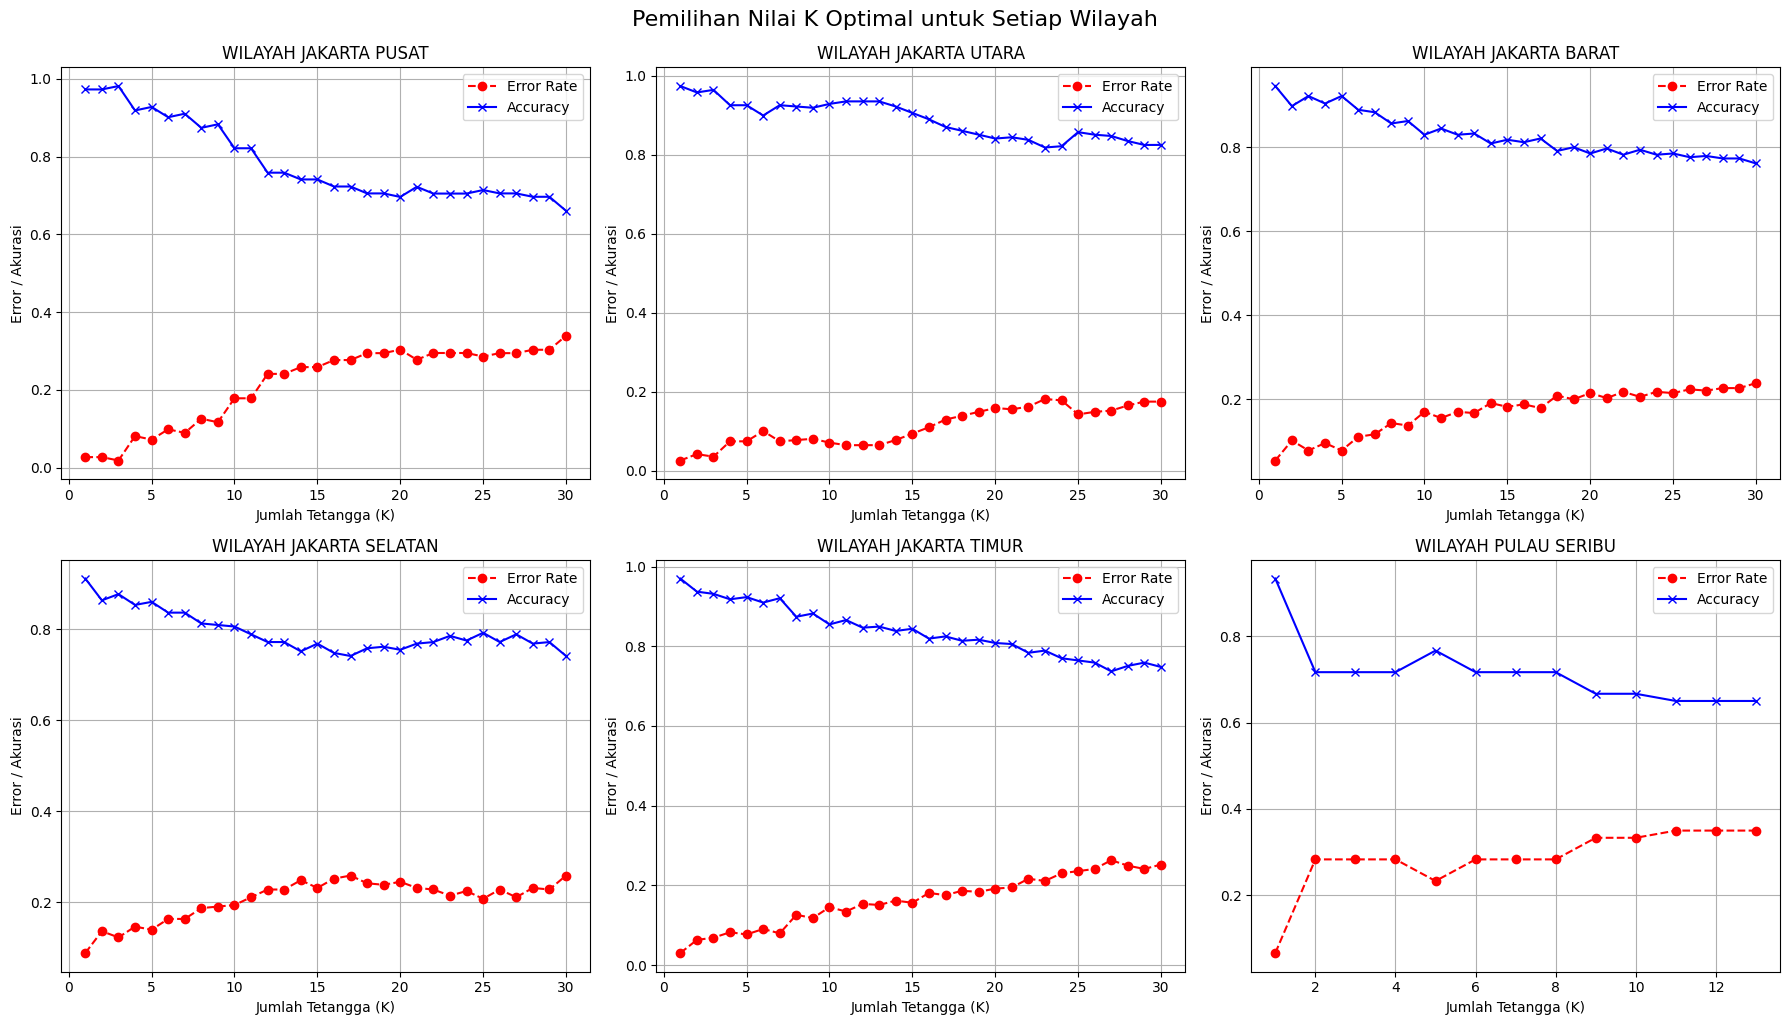

Nilai K Optimal untuk Setiap Wilayah
JAKARTA PUSAT: 3
JAKARTA UTARA: 1
JAKARTA BARAT: 1
JAKARTA SELATAN: 1
JAKARTA TIMUR: 1
PULAU SERIBU: 1


In [31]:
# ==========================
# 1. IMPORT LIBRARY
# ==========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ==========================
# 2. LOAD FILE DAN SHEET
# ==========================
file_path = "Cleaned Dataset.xlsx"  # Ganti jika nama file berbeda
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names

# ==========================
# 3. INISIASI FRAME PLOT
# ==========================
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()
best_k_list = []

# ==========================
# 4. LOOP UNTUK TIAP SHEET
# ==========================
for i, sheet in enumerate(sheet_names):
    df = pd.read_excel(file_path, sheet_name=sheet)
    df = df.dropna()

    # Asumsikan fitur = semua kolom kecuali terakhir, target = kolom terakhir
    X = df.iloc[:, 3:-1]
    y = df.iloc[:, -1]

    # Standarisasi
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=50)

    # Cari nilai K optimal
    error_rate = []
    cv_scores = []
    k_range = range(1, 31)

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        error_rate.append(1 - scores.mean())
        cv_scores.append(scores.mean())
    best_k = k_range[cv_scores.index(max(cv_scores))]
    best_k_list.append(best_k)

    # Plot
    axs[i].plot(k_range, error_rate, marker='o', linestyle='--', color='red', label='Error Rate')
    axs[i].plot(k_range, cv_scores, marker='x', linestyle='-', color='blue', label='Accuracy')
    axs[i].set_title(f'WILAYAH {sheet}', fontsize=12)
    axs[i].set_xlabel('Jumlah Tetangga (K)')
    axs[i].set_ylabel('Error / Akurasi')
    axs[i].legend()
    axs[i].grid(True)

# ==========================
# 5. TAMBAHAN PLOT
# ==========================
plt.tight_layout()
plt.suptitle('Pemilihan Nilai K Optimal untuk Setiap Wilayah', fontsize=16, y=1.02)
plt.show()

print("Nilai K Optimal untuk Setiap Wilayah")
for i, sheet in enumerate(sheet_names):
    print(f"{sheet}: {best_k_list[i]}")


===== Evaluasi untuk Sheet: JAKARTA PUSAT =====

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.90      1.00      0.95         9

    accuracy                           0.97        29
   macro avg       0.95      0.97      0.96        29
weighted avg       0.97      0.97      0.97        29



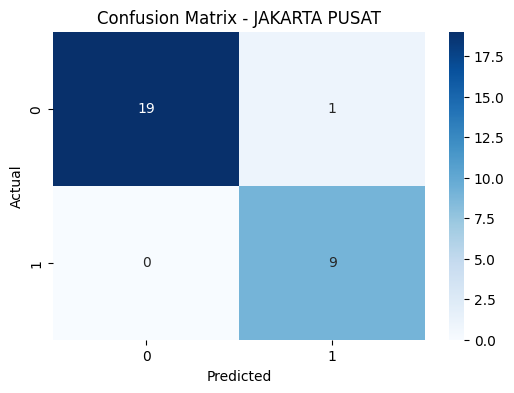


===== Evaluasi untuk Sheet: JAKARTA UTARA =====

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        29
         1.0       1.00      0.98      0.99        49

    accuracy                           0.99        78
   macro avg       0.98      0.99      0.99        78
weighted avg       0.99      0.99      0.99        78



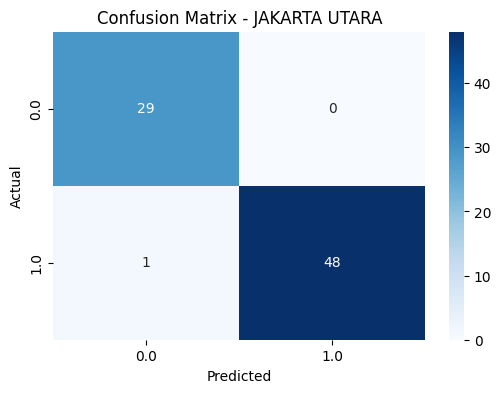


===== Evaluasi untuk Sheet: JAKARTA BARAT =====

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       1.00      0.98      0.99        51

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84



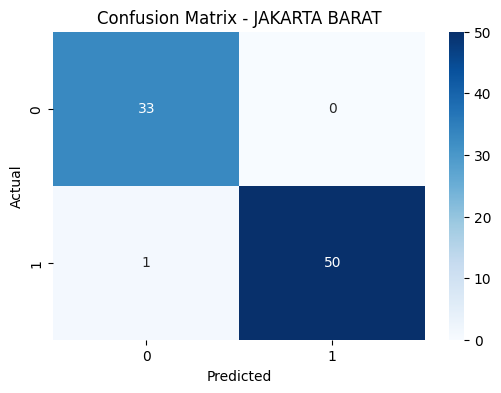


===== Evaluasi untuk Sheet: JAKARTA SELATAN =====

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        24
           1       0.98      0.96      0.97        50

    accuracy                           0.96        74
   macro avg       0.95      0.96      0.95        74
weighted avg       0.96      0.96      0.96        74



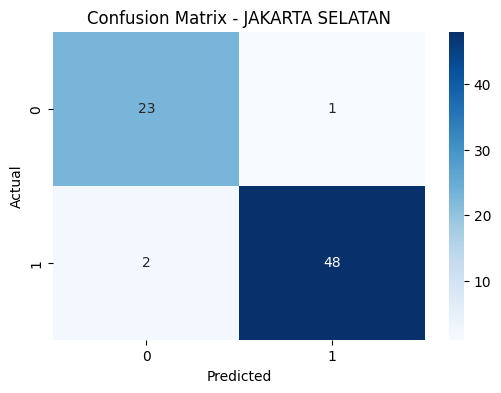


===== Evaluasi untuk Sheet: JAKARTA TIMUR =====

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        41
           1       0.98      0.94      0.96        51

    accuracy                           0.96        92
   macro avg       0.95      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



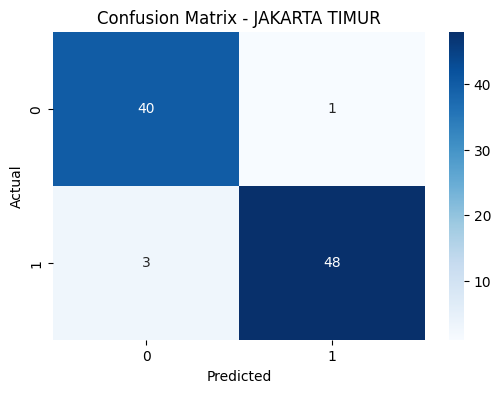


===== Evaluasi untuk Sheet: PULAU SERIBU =====

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



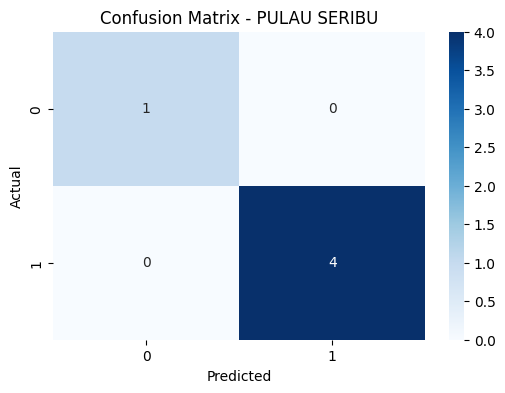

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ==========================
# 6. PEMODELAN DAN EVALUASI
# ==========================
for i, sheet in enumerate(sheet_names):
    print(f"\n===== Evaluasi untuk Sheet: {sheet} =====")

    # Muat data lagi
    df = pd.read_excel(file_path, sheet_name=sheet)
    df = df.dropna()
    X = df.iloc[:, 3:-1]
    y = df.iloc[:, -1]

    # Standarisasi
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data (tanpa stratify, asumsi aman berdasarkan sebelumnya)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=50)

    # Buat dan latih model KNN dengan k terbaik
    k_optimal = best_k_list[i]
    knn_model = KNeighborsClassifier(n_neighbors=k_optimal)
    knn_model.fit(X_train, y_train)

    # Prediksi
    y_pred = knn_model.predict(X_test)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix - {sheet}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
